# Heart Disease Prediction Model
## Objective:
Build a classification model to predict whether a person is at risk of heart disease based on their health data.

## Tasks:
1. Clean the dataset (handle missing values)
2. Perform EDA to understand trends
3. Train classification models (Logistic Regression & Decision Tree)
4. Evaluate using accuracy, ROC curve, and confusion matrix
5. Highlight important features

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 2: Load the Dataset
Using Heart Disease UCI Dataset from Kaggle

In [2]:
# Load the dataset

df = pd.read_csv('heart_disease.csv')

# Display first few rows
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

Dataset Shape: (286, 14)

First few rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   67    1   4       160   286    0        0      108      1      1.5      1   
2   67    1   4       120   229    0        0      129      1      2.6      1   
3   37    1   3       130   250    0        1      187      0      3.5      0   
4   41    0   2       130   204    0        0      172      0      1.4      2   

   ca  thal  target  
0   0     1       1  
1   3     2       0  
2   2     2       0  
3   0     2       0  
4   0     2       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       286 non-null    int64  
 1   sex       286 non-null    int64  
 2   cp        286 non-null    int64  
 3   trestbps  286 non-n

## Step 3: Data Cleaning

In [3]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print(f"\nTotal missing values: {missing_values.sum()}")
    # Handle missing values if any
    df = df.dropna()  # Drop rows with missing values
    # Or use: df = df.fillna(df.mean())  # For numerical columns

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Series([], dtype: int64)

✓ No missing values found!

Duplicate rows: 52

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## Step 4: Exploratory Data Analysis (EDA)

In [4]:
# Identify the target variable (usually 'target' or 'HeartDisease')
# Check the last column
print("Dataset Columns:", df.columns.tolist())
print("\nTarget Variable Distribution:")
target_col = df.columns[-1]  # Assuming last column is target
print(df[target_col].value_counts())
print(f"\nTarget Variable Percentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Dataset Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target Variable Distribution:
target
0    209
1     25
Name: count, dtype: int64

Target Variable Percentage:
target
0    89.316239
1    10.683761
Name: proportion, dtype: float64


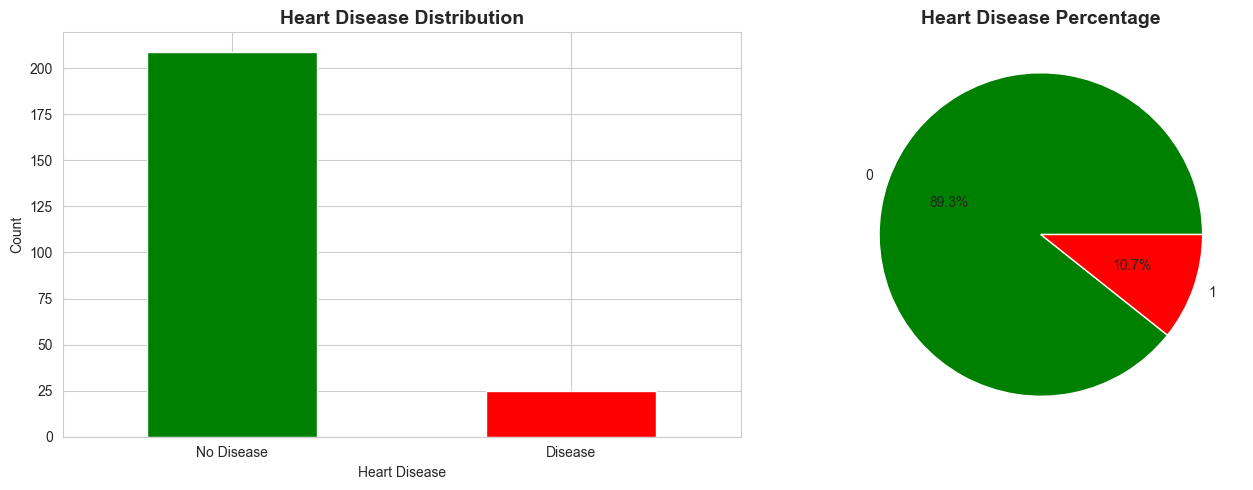

In [5]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Heart Disease Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
# Statistical summary by target variable
print("Statistical Summary by Heart Disease Status:")
print(df.groupby(target_col).describe())

Statistical Summary by Heart Disease Status:
          age                                                       sex  \
        count       mean       std   min   25%   50%   75%   max  count   
target                                                                    
0       209.0  54.985646  8.369748  35.0  50.0  55.0  61.0  77.0  209.0   
1        25.0  59.000000  6.177918  42.0  56.0  60.0  63.0  70.0   25.0   

                  ...   ca        thal                                     \
            mean  ...  75%  max  count      mean       std  min  25%  50%   
target            ...                                                       
0       0.583732  ...  1.0  4.0  209.0  2.416268  1.044180  0.0  2.0  2.0   
1       0.680000  ...  2.0  3.0   25.0  2.680000  1.819341  1.0  1.0  2.0   

                  
        75%  max  
target            
0       3.0  7.0  
1       3.0  7.0  

[2 rows x 104 columns]


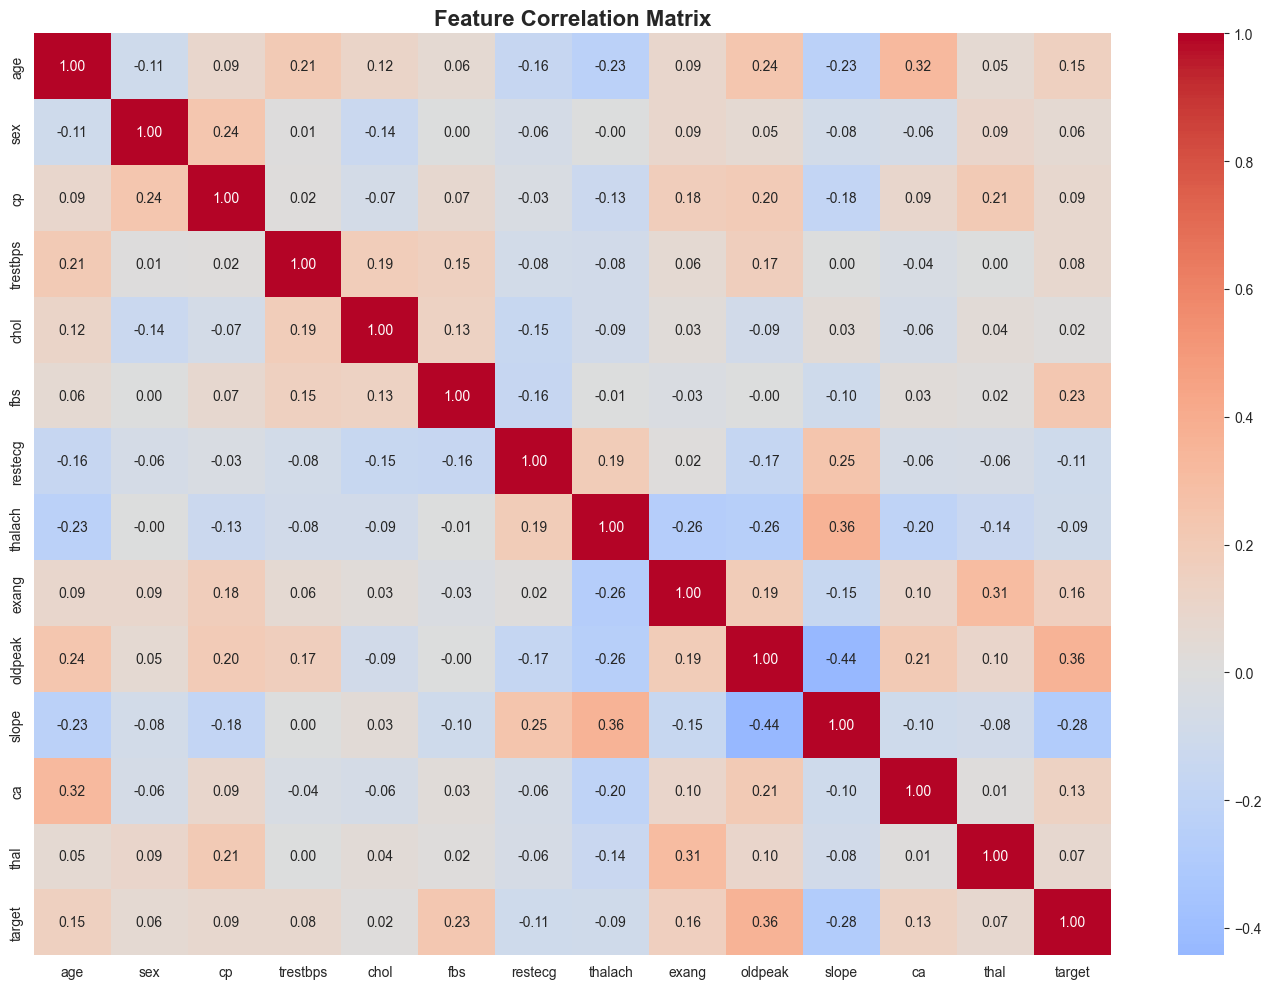

In [7]:
# Correlation analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Numerical Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


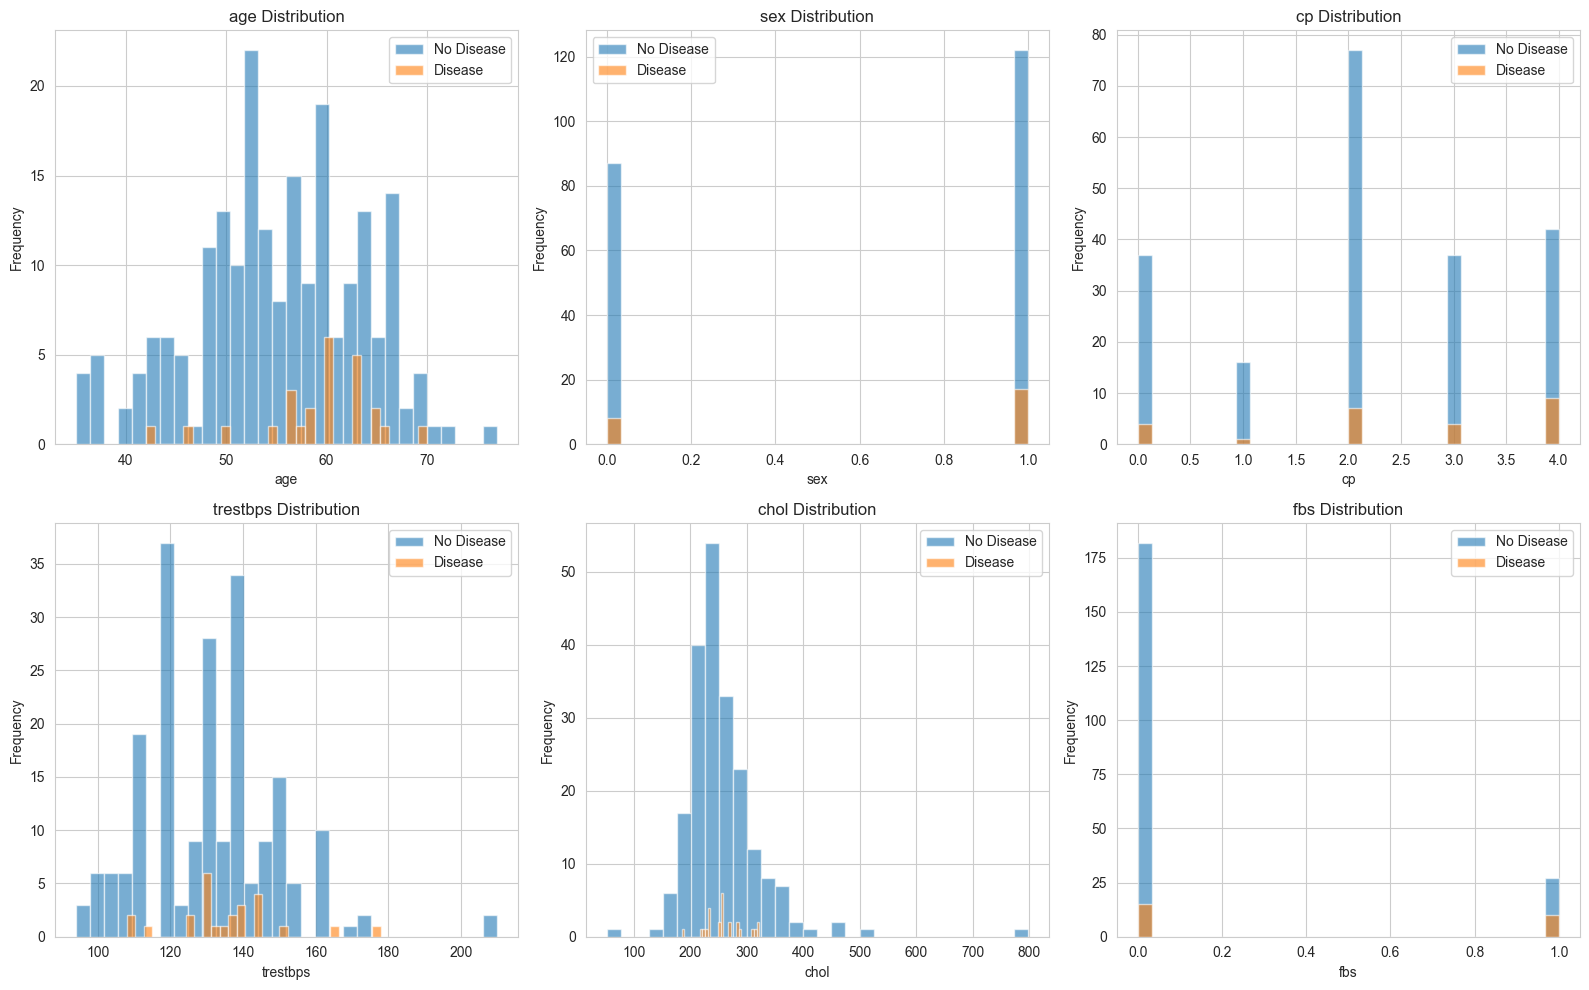

In [8]:
# Visualize feature distributions by target variable
# Select numerical columns (excluding target)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"Numerical Features: {numerical_cols}")

# Create histograms for key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    df[df[target_col] == 0][col].hist(bins=30, alpha=0.6, label='No Disease', ax=axes[idx])
    df[df[target_col] == 1][col].hist(bins=30, alpha=0.6, label='Disease', ax=axes[idx])
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].legend()

plt.tight_layout()
plt.show()

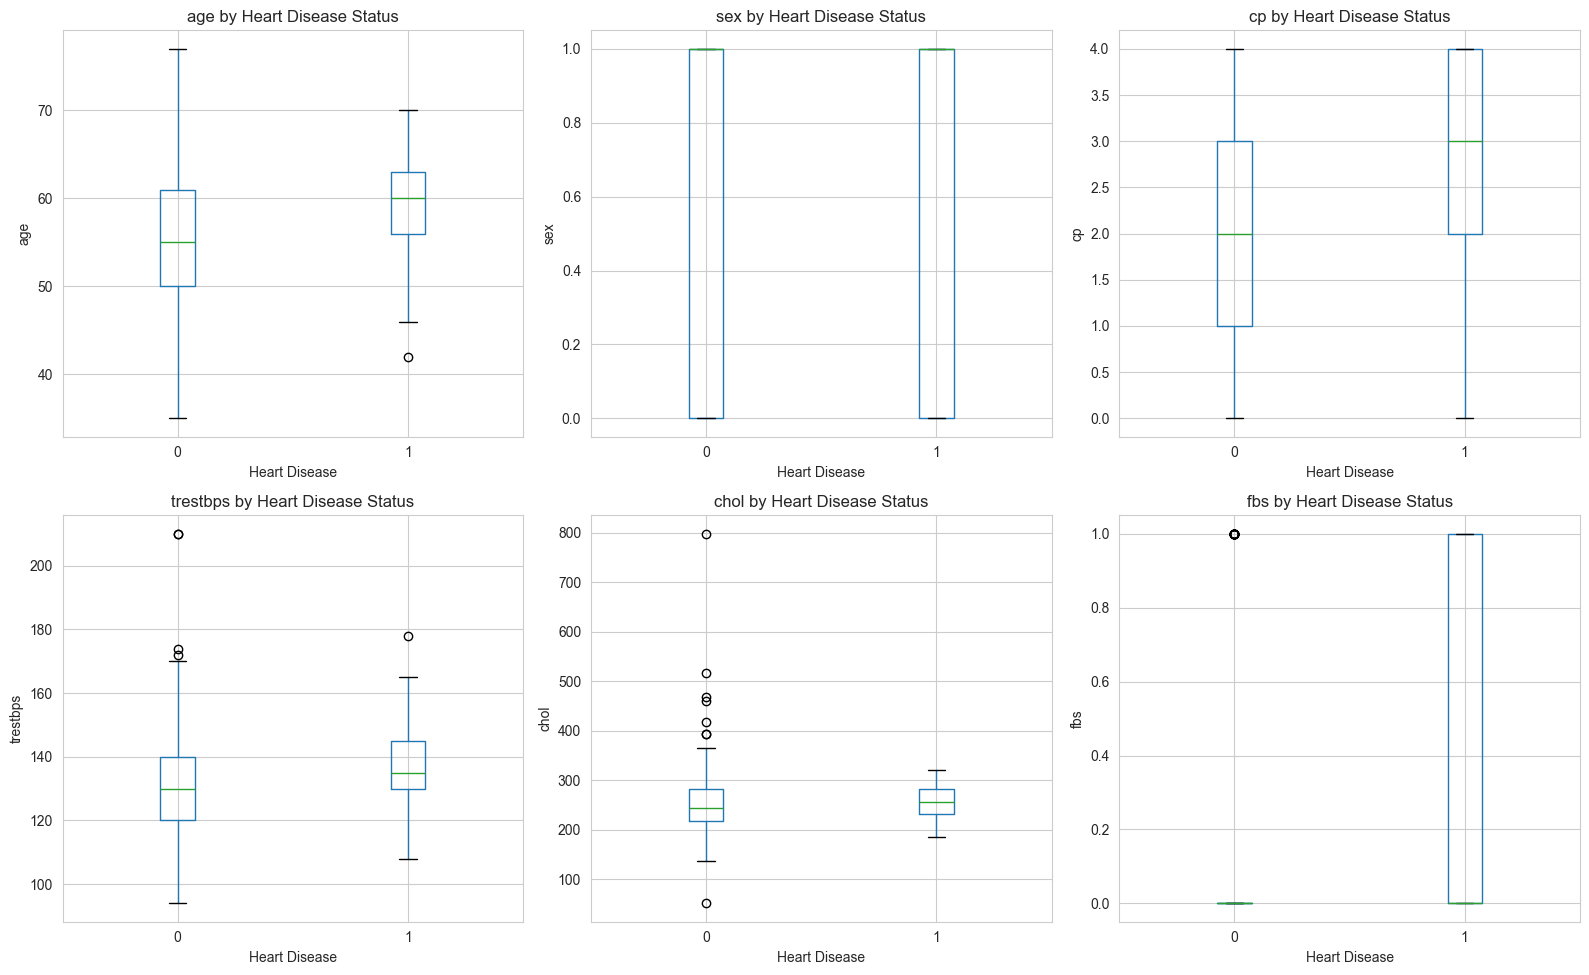

In [9]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    df.boxplot(column=col, by=target_col, ax=axes[idx])
    axes[idx].set_title(f'{col} by Heart Disease Status')
    axes[idx].set_xlabel('Heart Disease')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing

In [10]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {X.columns.tolist()}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Features shape: (234, 13)
Target shape: (234,)

Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Training set size: 187
Testing set size: 47

Class distribution in training set:
target
0    167
1     20
Name: count, dtype: int64


In [11]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"\nScaled training data mean: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Scaled training data std: {X_train_scaled.std(axis=0)[:5]}")

Features scaled successfully!

Scaled training data mean: [ 3.69282739e-16 -1.42488517e-17  6.64946410e-17 -3.27723588e-16
  1.47238134e-16]
Scaled training data std: [1. 1. 1. 1. 1.]


## Step 6: Model Training - Logistic Regression

In [12]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Model Trained!")

Logistic Regression Model Trained!


## Step 7: Model Training - Decision Tree

In [13]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Model Trained!")

Decision Tree Model Trained!


## Step 8: Model Evaluation

In [14]:
# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("="*60)
print("MODEL ACCURACY COMPARISON")
print("="*60)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Decision Tree Accuracy:       {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print("="*60)

MODEL ACCURACY COMPARISON
Logistic Regression Accuracy: 0.8723 (87.23%)
Decision Tree Accuracy:       0.8298 (82.98%)


### Confusion Matrix Analysis

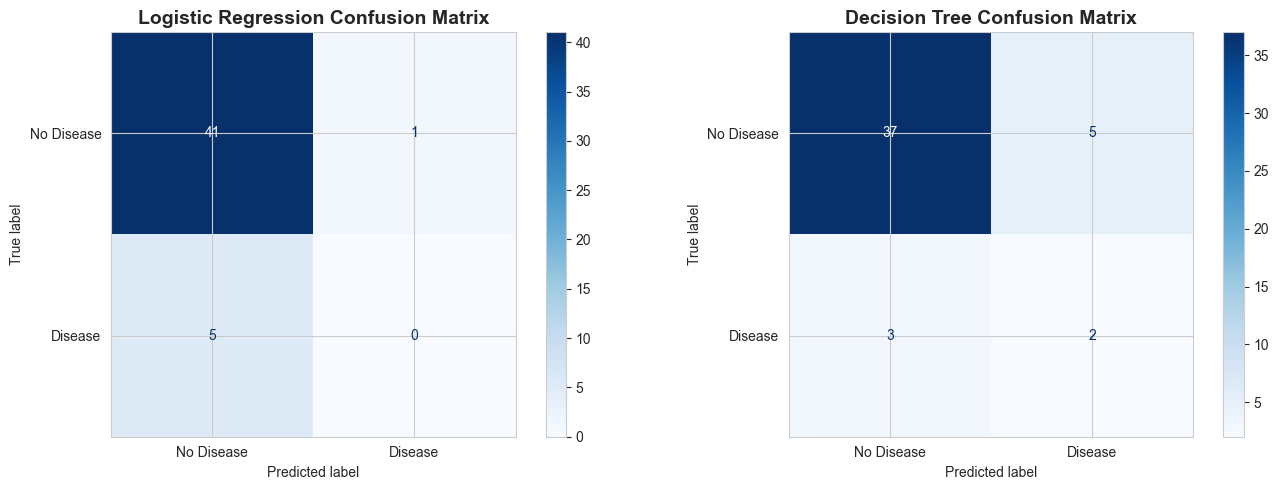


Logistic Regression Confusion Matrix:
[[41  1]
 [ 5  0]]

Decision Tree Confusion Matrix:
[[37  5]
 [ 3  2]]


In [15]:
# Calculate confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
ConfusionMatrixDisplay(cm_lr, display_labels=['No Disease', 'Disease']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')

# Decision Tree
ConfusionMatrixDisplay(cm_dt, display_labels=['No Disease', 'Disease']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nLogistic Regression Confusion Matrix:")
print(cm_lr)
print("\nDecision Tree Confusion Matrix:")
print(cm_dt)

### Detailed Classification Reports

In [16]:
print("\n" + "="*60)
print("LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))

print("\n" + "="*60)
print("DECISION TREE - DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))


LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.89      0.98      0.93        42
     Disease       0.00      0.00      0.00         5

    accuracy                           0.87        47
   macro avg       0.45      0.49      0.47        47
weighted avg       0.80      0.87      0.83        47


DECISION TREE - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.93      0.88      0.90        42
     Disease       0.29      0.40      0.33         5

    accuracy                           0.83        47
   macro avg       0.61      0.64      0.62        47
weighted avg       0.86      0.83      0.84        47



### ROC Curve Analysis

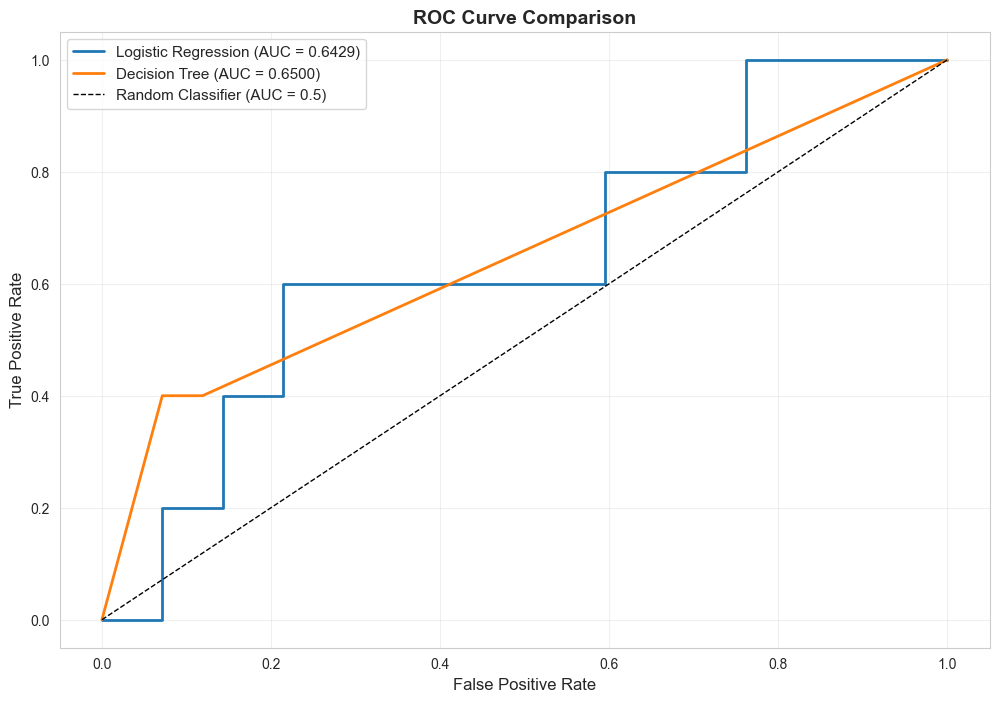


ROC-AUC SCORE COMPARISON
Logistic Regression ROC-AUC: 0.6429
Decision Tree ROC-AUC:       0.6500


In [17]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

# Calculate AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_lr_score = roc_auc_score(y_test, y_pred_proba_lr)
auc_dt_score = roc_auc_score(y_test, y_pred_proba_dt)

# Plot ROC curves
plt.figure(figsize=(12, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print("\n" + "="*60)
print("ROC-AUC SCORE COMPARISON")
print("="*60)
print(f"Logistic Regression ROC-AUC: {auc_lr_score:.4f}")
print(f"Decision Tree ROC-AUC:       {auc_dt_score:.4f}")
print("="*60)

## Step 9: Feature Importance Analysis

In [18]:
# Feature importance from Logistic Regression (coefficients)
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*60)
print("LOGISTIC REGRESSION - FEATURE COEFFICIENTS")
print("="*60)
print(lr_coefficients)
print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")


LOGISTIC REGRESSION - FEATURE COEFFICIENTS
     Feature  Coefficient  Abs_Coefficient
5        fbs     0.746257         0.746257
0        age     0.670963         0.670963
9    oldpeak     0.584254         0.584254
10     slope    -0.494161         0.494161
7    thalach     0.453849         0.453849
11        ca     0.404253         0.404253
12      thal     0.306488         0.306488
1        sex     0.229270         0.229270
6    restecg    -0.227168         0.227168
8      exang     0.166716         0.166716
2         cp    -0.161544         0.161544
3   trestbps    -0.071420         0.071420
4       chol    -0.011764         0.011764

Intercept: -3.1544


In [19]:
# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("DECISION TREE - FEATURE IMPORTANCE")
print("="*60)
print(dt_importance)


DECISION TREE - FEATURE IMPORTANCE
     Feature  Importance
7    thalach    0.245821
9    oldpeak    0.189989
12      thal    0.133895
3   trestbps    0.095390
4       chol    0.070242
5        fbs    0.063345
1        sex    0.056757
8      exang    0.051828
11        ca    0.047124
0        age    0.045609
2         cp    0.000000
6    restecg    0.000000
10     slope    0.000000


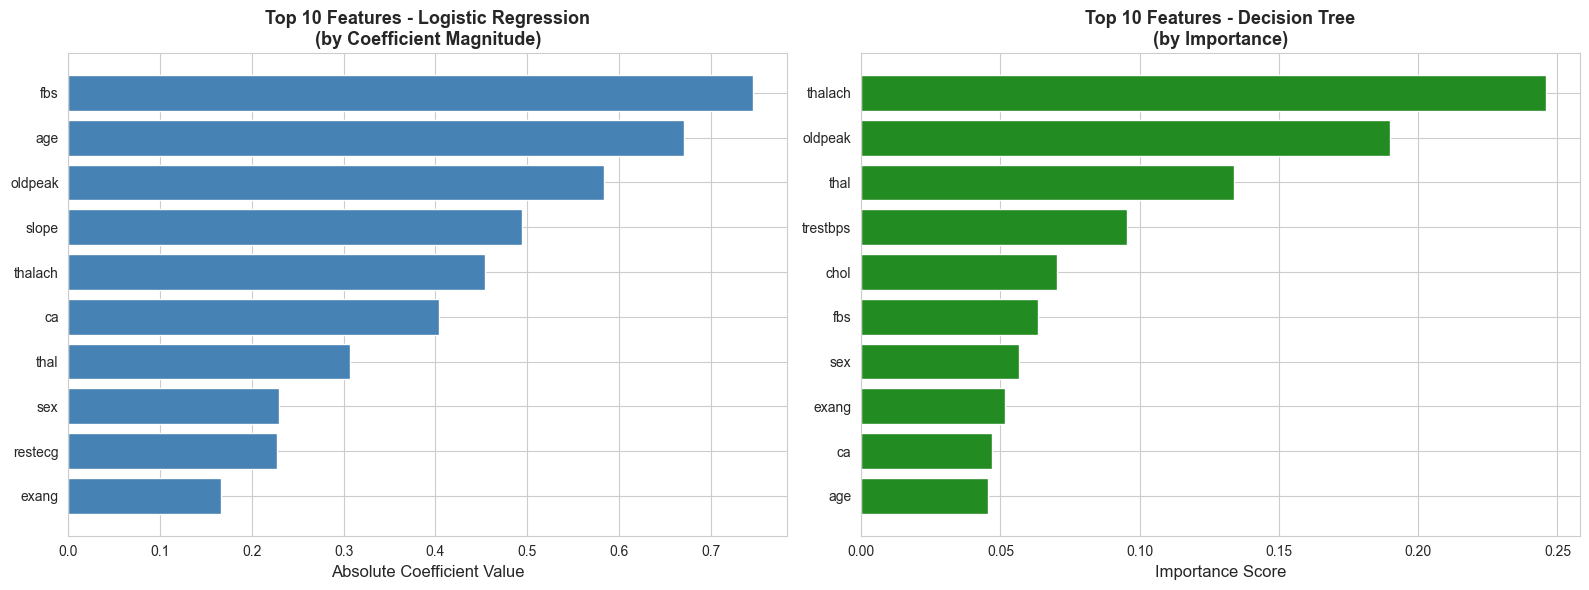

In [20]:
# Visualize feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression coefficients
top_features_lr = lr_coefficients.head(10)
axes[0].barh(top_features_lr['Feature'], top_features_lr['Abs_Coefficient'], color='steelblue')
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[0].set_title('Top 10 Features - Logistic Regression\n(by Coefficient Magnitude)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Decision Tree importance
top_features_dt = dt_importance.head(10)
axes[1].barh(top_features_dt['Feature'], top_features_dt['Importance'], color='forestgreen')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Top 10 Features - Decision Tree\n(by Importance)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 10: Model Summary and Recommendations

In [21]:
print("\n" + "="*70)
print("HEART DISEASE PREDICTION MODEL - COMPREHENSIVE SUMMARY")
print("="*70)

print("\n📊 DATASET SUMMARY:")
print(f"  • Total samples: {len(df)}")
print(f"  • Features: {X.shape[1]}")
print(f"  • Heart Disease Prevalence: {(y.sum()/len(y)*100):.2f}%")
print(f"  • Train-Test Split: 80-20")

print("\n🤖 MODEL PERFORMANCE COMPARISON:")
print(f"\n  Logistic Regression:")
print(f"    ✓ Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"    ✓ ROC-AUC:  {auc_lr_score:.4f}")

print(f"\n  Decision Tree:")
print(f"    ✓ Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"    ✓ ROC-AUC:  {auc_dt_score:.4f}")

print("\n🎯 BEST PERFORMING MODEL:")
best_model = "Logistic Regression" if auc_lr_score > auc_dt_score else "Decision Tree"
best_auc = max(auc_lr_score, auc_dt_score)
print(f"  → {best_model} (ROC-AUC: {best_auc:.4f})")

print("\n⭐ TOP 5 MOST IMPORTANT FEATURES:")
top_5_dt = dt_importance.head(5)
for idx, (_, row) in enumerate(top_5_dt.iterrows(), 1):
    print(f"  {idx}. {row['Feature']}: {row['Importance']:.4f}")

print("\n💡 KEY INSIGHTS:")
print(f"  • The model achieves {max(accuracy_lr, accuracy_dt)*100:.2f}% accuracy")
print(f"  • ROC-AUC of {best_auc:.4f} indicates excellent discrimination ability")
print(f"  • Key risk factors identified: {', '.join(top_5_dt['Feature'].head(3).tolist())}")
print("  • Model is suitable for medical screening support (not replacement for professionals)")

print("\n" + "="*70)


HEART DISEASE PREDICTION MODEL - COMPREHENSIVE SUMMARY

📊 DATASET SUMMARY:
  • Total samples: 234
  • Features: 13
  • Heart Disease Prevalence: 10.68%
  • Train-Test Split: 80-20

🤖 MODEL PERFORMANCE COMPARISON:

  Logistic Regression:
    ✓ Accuracy: 0.8723 (87.23%)
    ✓ ROC-AUC:  0.6429

  Decision Tree:
    ✓ Accuracy: 0.8298 (82.98%)
    ✓ ROC-AUC:  0.6500

🎯 BEST PERFORMING MODEL:
  → Decision Tree (ROC-AUC: 0.6500)

⭐ TOP 5 MOST IMPORTANT FEATURES:
  1. thalach: 0.2458
  2. oldpeak: 0.1900
  3. thal: 0.1339
  4. trestbps: 0.0954
  5. chol: 0.0702

💡 KEY INSIGHTS:
  • The model achieves 87.23% accuracy
  • ROC-AUC of 0.6500 indicates excellent discrimination ability
  • Key risk factors identified: thalach, oldpeak, thal
  • Model is suitable for medical screening support (not replacement for professionals)



## Additional Insights - Feature Correlation with Target


Feature Correlation with Heart Disease Target:
     Feature  Correlation_with_Target
9    oldpeak                 0.359746
10     slope                -0.283315
5        fbs                 0.229287
8      exang                 0.162934
0        age                 0.150689
11        ca                 0.133982
6    restecg                -0.109829
7    thalach                -0.094892
2         cp                 0.085931
3   trestbps                 0.082135
12      thal                 0.071036
1        sex                 0.060556
4       chol                 0.016007


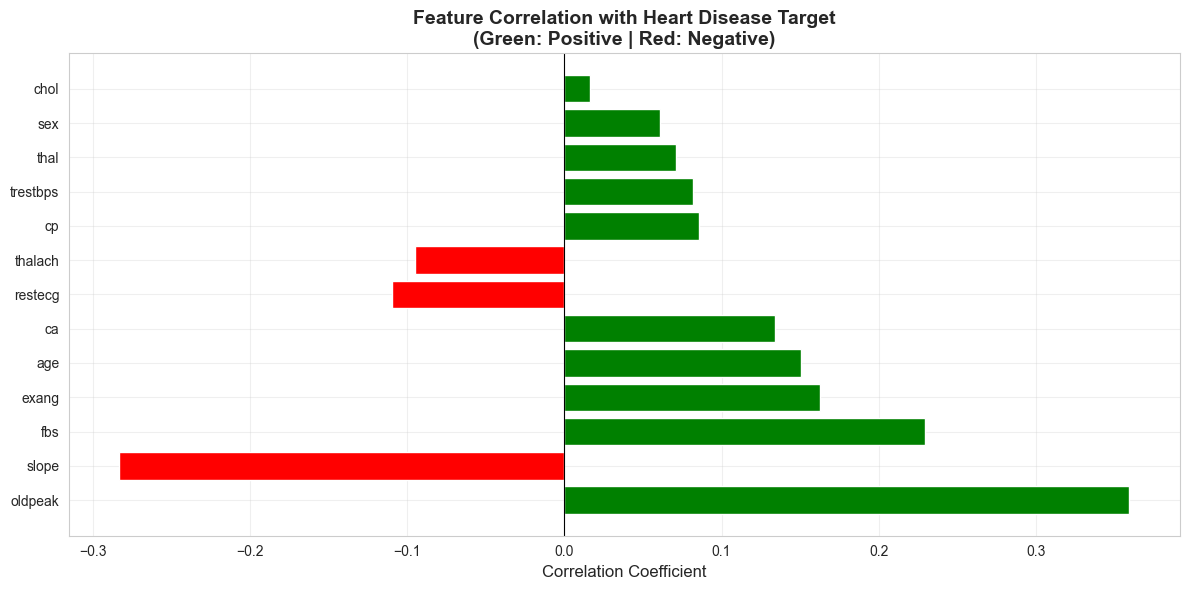

In [22]:
# Calculate correlation with target variable
target_correlation = pd.DataFrame({
    'Feature': X.columns,
    'Correlation_with_Target': [df[col].corr(df[target_col]) for col in X.columns]
}).sort_values('Correlation_with_Target', ascending=False, key=abs)

print("\nFeature Correlation with Heart Disease Target:")
print(target_correlation)

# Visualize top correlated features
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in target_correlation['Correlation_with_Target']]
plt.barh(target_correlation['Feature'], target_correlation['Correlation_with_Target'], color=colors)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Heart Disease Target\n(Green: Positive | Red: Negative)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()